## VITAFOAM STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

vitafoam=pd.read_csv('../stock_data/vitafoam.csv') ## so it can be small letter. This is cool.
vitafoam=vitafoam.drop(columns=['high_price','low_price'])
vitafoam.rename(columns={'trade_date':'date'},inplace=True)
vitafoam['date']=pd.to_datetime(vitafoam['date'])
vitafoam['month']=vitafoam['date'].dt.month
vitafoam['quarter']=vitafoam['date'].dt.quarter
vitafoam['year']=vitafoam['date'].dt.year

vitafoam

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42801,VITAFOAM,2017-01-03,2.42,2.42,1520901,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43361,VITAFOAM,2017-01-04,2.54,2.54,720150,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43471,VITAFOAM,2017-01-05,2.47,2.47,709921,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43581,VITAFOAM,2017-01-06,2.42,2.42,218157,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43671,VITAFOAM,2017-01-09,2.36,2.36,235274,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298157,VITAFOAM,2026-07-13,194.80,194.80,515083,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298595,VITAFOAM,2026-07-14,194.80,194.80,187780,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,299033,VITAFOAM,2026-07-15,194.80,194.80,113725,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299471,VITAFOAM,2026-07-16,194.80,194.80,429049,2026-07-16T15:10:03.113936+00:00,7,3,2026


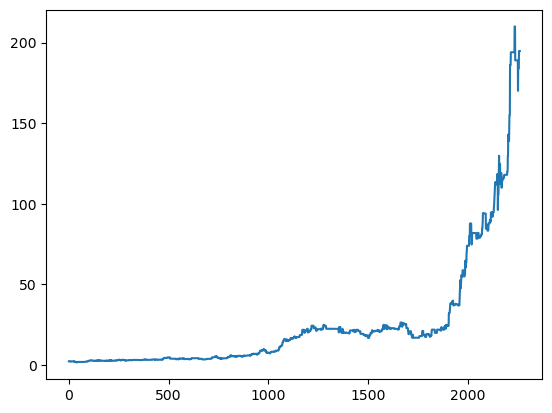

In [2]:
import matplotlib.pyplot as plt

plt.plot(vitafoam['close_price'])
plt.show()

In [3]:
vitafoam_end_month_df = (
    vitafoam
    .sort_values("date")
    .groupby(vitafoam["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

vitafoam_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45371,VITAFOAM,2017-01-31,2.39,2.39,565619,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47192,VITAFOAM,2017-02-28,1.72,1.72,72150,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49308,VITAFOAM,2017-03-31,1.95,1.95,80258,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51136,VITAFOAM,2017-04-28,2.00,2.00,1960856,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53058,VITAFOAM,2017-05-31,2.53,2.53,703093,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35395,VITAFOAM,2026-03-31,118.00,118.00,422942,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281220,VITAFOAM,2026-04-30,154.90,154.90,2085407,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284286,VITAFOAM,2026-05-29,194.00,194.00,319960,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294214,VITAFOAM,2026-06-30,189.00,189.00,88111,2026-06-30T15:10:03.08168+00:00,6,2,2026


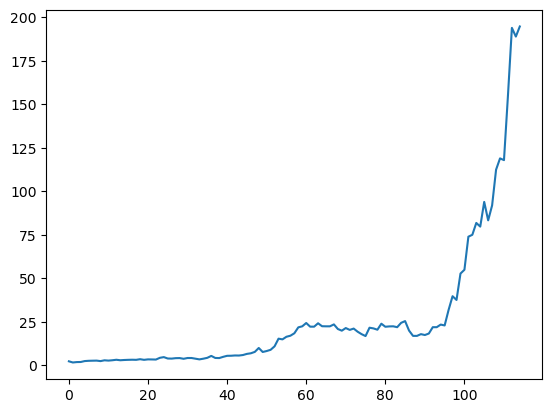

In [4]:
plt.plot(vitafoam_end_month_df['close_price'])
plt.show()

In [5]:
vitafoam_end_month_df['returns']=vitafoam_end_month_df['close_price'].pct_change()*100
vitafoam_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45371,VITAFOAM,2017-01-31,2.39,2.39,565619,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47192,VITAFOAM,2017-02-28,1.72,1.72,72150,2026-04-08T02:44:45.006295+00:00,2,1,2017,-28.033473
2,49308,VITAFOAM,2017-03-31,1.95,1.95,80258,2026-04-08T02:45:42.281198+00:00,3,1,2017,13.372093
3,51136,VITAFOAM,2017-04-28,2.00,2.00,1960856,2026-04-08T02:51:55.619599+00:00,4,2,2017,2.564103
4,53058,VITAFOAM,2017-05-31,2.53,2.53,703093,2026-04-08T02:52:57.421655+00:00,5,2,2017,26.500000
...,...,...,...,...,...,...,...,...,...,...,...
110,35395,VITAFOAM,2026-03-31,118.00,118.00,422942,2026-03-31T15:00:02.085058+00:00,3,1,2026,-0.840336
111,281220,VITAFOAM,2026-04-30,154.90,154.90,2085407,2026-04-30T15:00:02.170664+00:00,4,2,2026,31.271186
112,284286,VITAFOAM,2026-05-29,194.00,194.00,319960,2026-05-29T15:00:02.455558+00:00,5,2,2026,25.242092
113,294214,VITAFOAM,2026-06-30,189.00,189.00,88111,2026-06-30T15:10:03.08168+00:00,6,2,2026,-2.577320


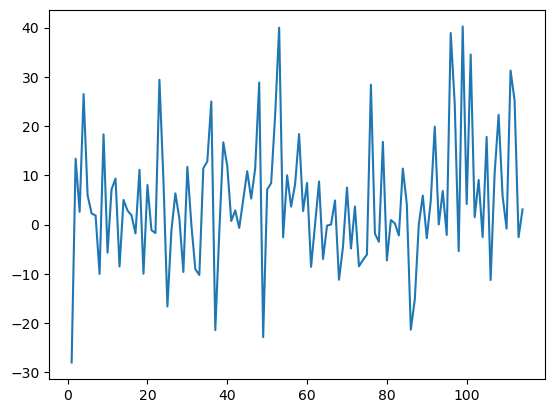

In [6]:
plt.plot(vitafoam_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(vitafoam_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(-11.443955717684682, 6.082540113726859e-21, 0, 113, {'1%': -3.489589552580676, '5%': -2.887477210140433, '10%': -2.580604145195395}, 799.6444222381309)
stationary


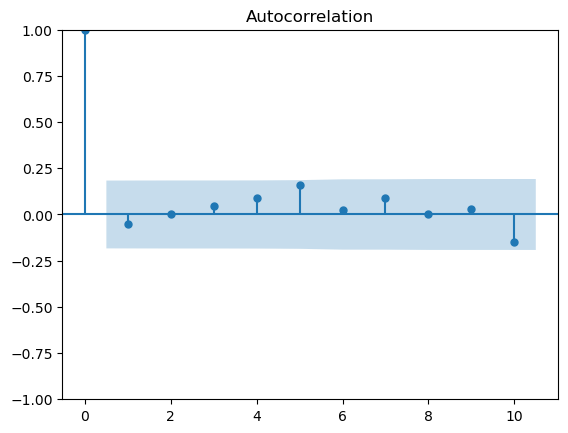

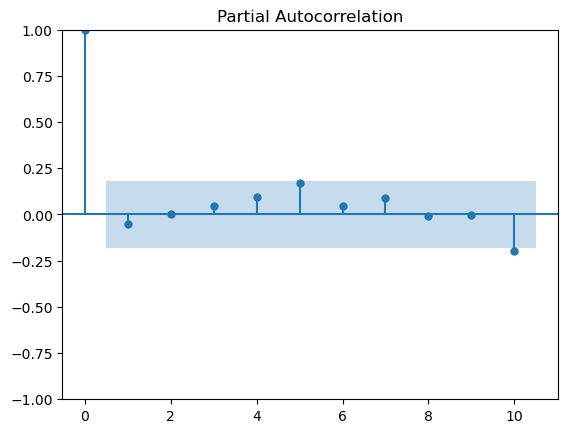

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(vitafoam_end_month_df['returns'].dropna(), lags=10)
plot_pacf(vitafoam_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=vitafoam_end_month_df['close_price'][:-10]
test=vitafoam_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -10.372245694049559]
[0, 0, 0, 0, 0, 1, -6.297874053720271]
[0, 0, 0, 0, 0, 2, -4.582115778502134]
[0, 0, 0, 0, 1, 0, -4.112734891444787]
[0, 0, 0, 0, 1, 1, -4.285444989292764]
[0, 0, 0, 0, 1, 2, -6.576285424402011]
[0, 0, 0, 0, 2, 0, -1.769011044591141]
[0, 0, 0, 0, 2, 1, -3.062033809141888]
[0, 0, 0, 0, 2, 2, -3.4799841999135257]
[0, 0, 0, 1, 0, 0, -4.704097155036467]
[0, 0, 0, 1, 0, 1, -5.135555250873203]
[0, 0, 0, 1, 0, 2, -7.066664213207229]
[0, 0, 0, 1, 1, 0, -4.285101914088051]
[0, 0, 0, 1, 1, 1, -4.289234883820889]
[0, 0, 0, 1, 1, 2, -4.1494817541645155]
[0, 0, 0, 1, 2, 0, -2.286834841518664]
[0, 0, 0, 1, 2, 1, -3.2414604972292604]
[0, 0, 0, 1, 2, 2, -4.196693195467301]
[0, 0, 0, 2, 0, 0, -5.187613055339783]
[0, 0, 0, 2, 0, 1, -5.200899198873663]
[0, 0, 0, 2, 0, 2, -4.992165340046909]
[0, 0, 0, 2, 1, 0, -4.279778823155021]
[0, 0, 0, 2, 1, 1, -4.267196232652653]
[0, 0, 0, 2, 1, 2, -5.223823524209074]
[0, 0, 0, 2, 2, 0, -2.917140804248597]
[0, 0, 0, 2, 2, 1, -3

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
0,0,0,0,0,0,0,-10.372246
27,0,0,1,0,0,0,-10.158665
54,0,0,2,0,0,0,-9.702507
11,0,0,0,1,0,2,-7.066664
5,0,0,0,0,1,2,-6.576285
...,...,...,...,...,...,...,...
87,0,1,0,0,2,0,0.856201
196,0,2,1,0,2,1,0.856912
195,0,2,1,0,2,0,0.872396
213,0,2,1,2,2,0,0.875914


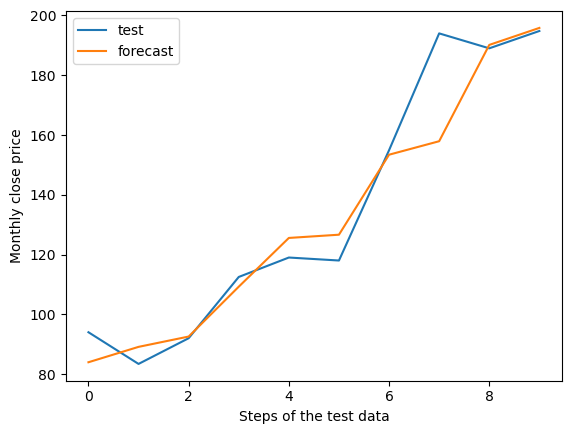

r2_score:  0.9109454699994027
rmse:  12.523905825686485
description:  count    115.000000
mean      26.172522
std       39.262267
min        1.720000
25%        4.100000
50%       17.000000
75%       22.500000
max      194.800000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=vitafoam_end_month_df['close_price'][:-10]
y_test=vitafoam_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(0,2,1), 
seasonal_order=(1,2,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', vitafoam_end_month_df.close_price.describe())

EXCELLENT.